In [1]:
import sys
print(sys.version)

3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]


In [2]:
import requests
import bs4
import pandas
import matplotlib
import seaborn
import scipy
import re
import time
import json

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
import requests

url = "https://www.magicbricks.com/property-for-sale/residential-real-estate?proptype=Multistorey-Apartment,Builder-Floor-Apartment,Penthouse,Studio-Apartment&cityName=Navi-Mumbai"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)

print("Status code:", response.status_code)
print("Response size:", len(response.text), "characters")

Status code: 200
Response size: 1107304 characters


In [4]:
# Extract all property URLs first
urls = re.findall(r'"url":"(https://www\.magicbricks\.com/propertyDetails/.*?)"', response.text)

print(f"Total listings found: {len(urls)}")
print("\nFirst 3 URLs:")
for url in urls[:3]:
    print(url)

Total listings found: 60

First 3 URLs:
https://www.magicbricks.com/propertyDetails/3-BHK-1975-Sq-ft-Multistorey-Apartment-FOR-Sale-Kharghar-in-Navi-Mumbai&id=4d423835323436303933
https://www.magicbricks.com/propertyDetails/3-BHK-1275-Sq-ft-Multistorey-Apartment-FOR-Sale-Sector-9-Ulwe-in-Navi-Mumbai&id=4d423834393831353235
https://www.magicbricks.com/propertyDetails/3-BHK-1267-Sq-ft-Multistorey-Apartment-FOR-Sale-Sanpada-in-Navi-Mumbai&id=4d423835323433383133


In [5]:
# We'll store each listing as a dictionary
listings = []

for url in urls:
    # Extract the property details part from the URL
    # Example: "4-BHK-1619-Sq-ft-Multistorey-Apartment-FOR-Sale-Ghansoli-in-Navi-Mumbai"
    match = re.search(
        r'propertyDetails/(\d+)-BHK-(\d+)-Sq-ft-[\w-]+-FOR-Sale-([\w]+)-in-Navi-Mumbai',
        url
    )
    
    if match:
        bhk      = int(match.group(1))   # e.g. 4
        area     = int(match.group(2))   # e.g. 1619
        locality = match.group(3)        # e.g. Ghansoli
        
        listings.append({
            "bhk"      : bhk,
            "area_sqft": area,
            "locality" : locality
        })

print(f"Successfully parsed: {len(listings)} listings")
print("\nFirst 5:")
for l in listings[:5]:
    print(l)

Successfully parsed: 48 listings

First 5:
{'bhk': 3, 'area_sqft': 1975, 'locality': 'Kharghar'}
{'bhk': 3, 'area_sqft': 1267, 'locality': 'Sanpada'}
{'bhk': 3, 'area_sqft': 1140, 'locality': 'Kharghar'}
{'bhk': 3, 'area_sqft': 1008, 'locality': 'Ghansoli'}
{'bhk': 3, 'area_sqft': 1268, 'locality': 'Kharghar'}


In [6]:
import pandas as pd

# Convert our list of dictionaries into a DataFrame
df = pd.DataFrame(listings)

# Let's see what we have
print(df.shape)   # rows, columns
print()
df.head(10)       # first 10 rows

(48, 3)



,bhk,area_sqft,locality
0,3,1975,Kharghar
1,3,1267,Sanpada
2,3,1140,Kharghar
3,3,1008,Ghansoli
4,3,1268,Kharghar
5,3,679,Seawoods
6,3,1080,Nerul
7,3,1271,Kharghar
8,2,728,Rohinjan
9,2,690,Panvel


In [7]:
# Get a summary of the entire DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   bhk        48 non-null     int64 
 1   area_sqft  48 non-null     int64 
 2   locality   48 non-null     object
dtypes: int64(2), object(1)
memory usage: 1.3+ KB


In [8]:
# Each listing object starts with "price": and has "priceD" nearby
# Let's extract all priceD values and their surrounding context

matches = re.findall(
    r'"devName":"(.*?)".*?"price":(\d+).*?"priceD":"(.*?)".*?"seoDesc":"(.*?)"',
    response.text
)

print(f"Listings with full data: {len(matches)}")
print("\nFirst 3:")
for m in matches[:3]:
    print({
        "developer": m[0],
        "price_raw": m[1],
        "price_fmt": m[2],
        "description": m[3]
    })

Listings with full data: 29

First 3:
{'developer': 'Punit Reality', 'price_raw': '23752000', 'price_fmt': '2.37 Cr', 'description': "Kharghar, Navi Mumbai has a 3 BHK apartment for sale with various amenities. This flat is situated in Punit Imperia and is equipped with premium facilities. This jul '27 property in Kharghar is available at a cost of ₹2.37 Cr.P52000053173 is the RERA number of the project. Properties in Punit Imperia are available in 2,3 bhk flats, priced between ₹1.41 Cr - ₹2.37 Cr. "}
{'developer': 'Bhumikar Infra LLP', 'price_raw': '13800000', 'price_fmt': '1.38 Cr', 'description': "This ready to move-in 3 BHK flat is available for sale at the premium Sector 9 Ulwe locality in Navi Mumbai.It is located in Bhumikar Guru Anmol. Costing ₹1.38 Cr, this dec '30 apartment in Sector 9 Ulwe is a great buy. Its possession date is Dec '30. P51700080046 is the RERA number of the project. Property rates in Bhumikar Guru Anmol fall within ₹82 Lac - ₹1.38 Cr, with multiple 1,2,3 bh

In [9]:
def extract_locality(desc):
    # Pattern 1: "in Ghansoli, Navi Mumbai"
    m = re.search(r'in\s+([\w\s]+),\s+Navi Mumbai', desc)
    if m:
        return m.group(1).strip()
    
    # Pattern 2: "prime location of Panvel" or "location of Kharghar"
    m = re.search(r'location of\s+([\w\s]+?)[,\.]', desc)
    if m:
        return m.group(1).strip()
    
    # Pattern 3: "Panvel, Navi Mumbai has"
    m = re.search(r'^([\w\s]+),\s+Navi Mumbai\s+has', desc)
    if m:
        return m.group(1).strip()
    
    # Pattern 4: "premium Kharghar locality"
    m = re.search(r'premium\s+([\w\s]+?)\s+locality', desc)
    if m:
        return m.group(1).strip()

    # Pattern 5: "4 BHK flat in Panvel is"
    m = re.search(r'\d+\s+BHK\s+\w+\s+in\s+([\w\s]+?)\s+is', desc)
    if m:
        return m.group(1).strip()

    # Pattern 6: "apartment in Seawoods to"
    m = re.search(r'apartment in\s+([\w\s]+?)\s+to', desc)
    if m:
        return m.group(1).strip()

    return None

# Test again
for m in matches:
    desc = m[3]
    locality = extract_locality(desc)
    display = locality if locality else "NOT FOUND"
    print(f"{display:20} | {desc[:60]}")

Kharghar             | Kharghar, Navi Mumbai has a 3 BHK apartment for sale with va
Sector 9 Ulwe        | This ready to move-in 3 BHK flat is available for sale at th
Sanpada              | This 3 BHK flat is in Sanpada, Navi Mumbai.The flat has a pr
Kharghar             | This ready to move-in 3 BHK flat is available for sale at th
Ghansoli             | A 3 BHK apartment is available for sale in Ghansoli, Navi Mu
Kharghar             | A 3 BHK apartment is available for sale in Kharghar, Navi Mu
Nerul                | Situated in the prime location of Nerul, the 3 BHK flat is c
Kharghar             | 3 BHK flat is offered for sale in Kharghar, Navi Mumbai.This
NOT FOUND            | The 2 BHK apartment is located in a well-connected area of R
Panvel               | 2 BHK flat available for sale in Navi Mumbai in the prime lo
Panvel               | The 3 BHK flat is available for sale in Panvel, Navi Mumbai.
Panvel               | This 4 BHK home in Panvel, Navi Mumbai is available f

In [10]:
def parse_listing(block):
    """Extract all fields from one listing's JSON block"""
    
    # Price
    price_match = re.search(r'"price":(\d+)', block)
    price = int(price_match.group(1)) if price_match else None
    
    # Formatted price
    price_fmt_match = re.search(r'"priceD":"(.*?)"', block)
    price_fmt = price_fmt_match.group(1) if price_fmt_match else None
    
    # Developer
    dev_match = re.search(r'"devName":"(.*?)"', block)
    developer = dev_match.group(1) if dev_match else None
    
    # Description
    desc_match = re.search(r'"seoDesc":"(.*?)"', block)
    desc = desc_match.group(1) if desc_match else ""
    
    # BHK from description
    bhk_match = re.search(r'(\d+)\s+BHK', desc)
    bhk = int(bhk_match.group(1)) if bhk_match else None
    
    # Locality from description
    locality = extract_locality(desc)
    
    # Area sqft from description e.g. "carpet area 360 sqft"
    area_match = re.search(r'carpet area\s+(\d+)\s+sqft', desc)
    area = int(area_match.group(1)) if area_match else None
    
    # Project name from description e.g. "located in Siddhivinayak Apartment"
    project_match = re.search(r'located in\s+(.*?)[,\.]', desc)
    project = project_match.group(1).strip() if project_match else None
    
    # Possession date e.g. "dec '31" or "ready to move"
    possess_match = re.search(r'(ready to move|[\w]+\s+\'\d+)', desc, re.IGNORECASE)
    possession = possess_match.group(1).strip() if possess_match else None
    
    # Landmarks - extract by category code
    landmarks = re.findall(r'"(\d+)\|([^"]+)"', block)
    
    railway  = [name for code, name in landmarks if code == "19210"]
    hospital = [name for code, name in landmarks if code == "19203"]
    market   = [name for code, name in landmarks if code == "19206"]
    
    # Take first of each (nearest one)
    nearest_railway  = railway[0]  if railway  else None
    nearest_hospital = hospital[0] if hospital else None
    nearest_market   = market[0]   if market   else None
    
    return {
        "bhk"             : bhk,
        "price"           : price,
        "price_fmt"       : price_fmt,
        "locality"        : locality,
        "developer"       : developer,
        "project"         : project,
        "area_sqft"       : area,
        "possession"      : possession,
        "nearest_railway/metro_station" : nearest_railway,
        "nearest_hospital": nearest_hospital,
        "nearest_market"  : nearest_market
    }

print("Function defined successfully!")

Function defined successfully!


In [11]:
all_blocks = []

for page in range(1, 51):  # Pages 1 to 50
    
    url = f"https://www.magicbricks.com/property-for-sale/residential-real-estate?proptype=Multistorey-Apartment,Builder-Floor-Apartment,Penthouse,Studio-Apartment&cityName=Navi-Mumbai&page={page}"
    
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        # Extract individual listing blocks
        # Each block starts with "devName" and ends after "seoDesc"
        blocks = re.findall(
            r'\{[^{}]*"devName":".*?"seoDesc":".*?"\}',
            response.text,
            re.DOTALL
        )
        all_blocks.extend(blocks)
        print(f"Page {page}: {len(blocks)} blocks (total: {len(all_blocks)})")
    else:
        print(f"Page {page}: Failed with status {response.status_code}")
    
    time.sleep(2)

print(f"\nDone! Total blocks collected: {len(all_blocks)}")

Page 1: 28 blocks (total: 28)
Page 2: 29 blocks (total: 57)
Page 3: 22 blocks (total: 79)
Page 4: 26 blocks (total: 105)
Page 5: 22 blocks (total: 127)
Page 6: 18 blocks (total: 145)
Page 7: 19 blocks (total: 164)
Page 8: 19 blocks (total: 183)
Page 9: 22 blocks (total: 205)
Page 10: 25 blocks (total: 230)
Page 11: 25 blocks (total: 255)
Page 12: 25 blocks (total: 280)
Page 13: 24 blocks (total: 304)
Page 14: 25 blocks (total: 329)
Page 15: 22 blocks (total: 351)
Page 16: 23 blocks (total: 374)
Page 17: 27 blocks (total: 401)
Page 18: 24 blocks (total: 425)
Page 19: 24 blocks (total: 449)
Page 20: 27 blocks (total: 476)
Page 21: 14 blocks (total: 490)
Page 22: 0 blocks (total: 490)
Page 23: 23 blocks (total: 513)
Page 24: 29 blocks (total: 542)
Page 25: 27 blocks (total: 569)
Page 26: 28 blocks (total: 597)
Page 27: 29 blocks (total: 626)
Page 28: 29 blocks (total: 655)
Page 29: 29 blocks (total: 684)
Page 30: 26 blocks (total: 710)
Page 31: 16 blocks (total: 726)
Page 32: 14 blocks (t

In [12]:
parsed_listings = []

for block in all_blocks:
    listing = parse_listing(block)
    parsed_listings.append(listing)

df_rich = pd.DataFrame(parsed_listings)

print(f"Total rows: {len(df_rich)}")
print(f"\nMissing values per column:")
print(df_rich.isna().sum())
print(f"\nSample:")
print(df_rich.head(3).to_string())

Total rows: 1227

Missing values per column:
bhk                                1
price                              0
price_fmt                          0
locality                          61
developer                          0
project                          826
area_sqft                        553
possession                       110
nearest_railway/metro_station    280
nearest_hospital                 302
nearest_market                   480
dtype: int64

Sample:
   bhk     price price_fmt       locality              developer              project  area_sqft     possession     nearest_railway/metro_station  nearest_hospital                                                  nearest_market
0  3.0  23752000   2.37 Cr       Kharghar          Punit Reality                 None        NaN        jul '27  Pethpada Metro Station|5 minutes  Ariella Hospital                                                      Prime Mall
1  3.0  13800000   1.38 Cr  Sector 9 Ulwe     Bhumikar Infra LLP  Bhum

In [13]:
# Step 1: Drop rows where critical fields are missing
df_clean = df_rich.dropna(subset=["locality", "bhk", "price"])

print(f"After dropping missing locality/bhk/price: {len(df_clean)} rows")

# Step 2: Remove duplicate listings (same price + locality + bhk)
df_clean = df_clean.drop_duplicates(subset=["price", "locality", "bhk"])

print(f"After removing duplicates: {len(df_clean)} rows")

# Step 3: Convert bhk to integer (it's currently float because of the one missing value)
df_clean["bhk"] = df_clean["bhk"].astype(int)

# Step 4: Add price per sqft only where area is available
df_clean_with_area = df_clean.dropna(subset=["area_sqft"]).copy()
df_clean_with_area["price_per_sqft"] = (df_clean_with_area["price"] / df_clean_with_area["area_sqft"]).round(0)

print(f"Rows with area data for price/sqft analysis: {len(df_clean_with_area)}")

# Step 5: Save both versions
df_clean.to_csv("navi_mumbai_full.csv", index=False)
df_clean_with_area.to_csv("navi_mumbai_with_area.csv", index=False)

print("\nBoth files saved!")

After dropping missing locality/bhk/price: 1166 rows
After removing duplicates: 809 rows
Rows with area data for price/sqft analysis: 432

Both files saved!


In [14]:
# Keep only localities with 10+ listings for reliable analysis
locality_counts = df_clean["locality"].value_counts()
valid_localities = locality_counts[locality_counts >= 10].index.tolist()

print(f"Localities with 10+ listings: {len(valid_localities)}")
print(valid_localities)

# Filter both DataFrames
df_main = df_clean[df_clean["locality"].isin(valid_localities)].copy()
df_area = df_clean_with_area[df_clean_with_area["locality"].isin(valid_localities)].copy()

print(f"\nRows in main dataset: {len(df_main)}")
print(f"Rows with area data: {len(df_area)}")

Localities with 10+ listings: 17
['Panvel', 'Kharghar', 'Ulwe', 'Taloja', 'New Panvel', 'Sanpada', 'Roadpali', 'Kamothe', 'Ghansoli', 'Karanjade', 'Airoli', 'Nerul', 'Kopar Khairane', 'Taloja Panchanand', 'Kalamboli', 'Dronagiri', 'Seawoods']

Rows in main dataset: 685
Rows with area data: 365


In [15]:
# Average price per sqft by locality - sorted cheapest first
price_analysis = df_area.groupby("locality")["price_per_sqft"].agg(["mean", "median", "count"]).round(0)
price_analysis.columns = ["avg_price_sqft", "median_price_sqft", "listings"]
price_analysis = price_analysis.sort_values("median_price_sqft")

print("Price per Sq Ft by Locality (cheapest first):")
print()
print(f"{'Locality':<20} {'Avg ₹/sqft':>12} {'Median ₹/sqft':>15} {'Listings':>10}")
print("-" * 60)
for locality, row in price_analysis.iterrows():
    print(f"{locality:<20} {row['avg_price_sqft']:>12,.0f} {row['median_price_sqft']:>15,.0f} {row['listings']:>10.0f}")

Price per Sq Ft by Locality (cheapest first):

Locality               Avg ₹/sqft   Median ₹/sqft   Listings
------------------------------------------------------------
Taloja                      8,427           7,995         38
Taloja Panchanand           8,175           8,173          9
New Panvel                 10,277           9,336         29
Panvel                     10,724           9,585         77
Karanjade                  10,674           9,908         12
Kalamboli                  10,986          10,171         11
Dronagiri                  11,875          10,858          6
Roadpali                   11,901          11,607         13
Kamothe                    12,932          12,578         22
Ulwe                       13,641          12,789         40
Kharghar                   14,594          13,150         56
Ghansoli                   19,730          18,156         14
Airoli                     21,296          19,423         12
Kopar Khairane             20,717     

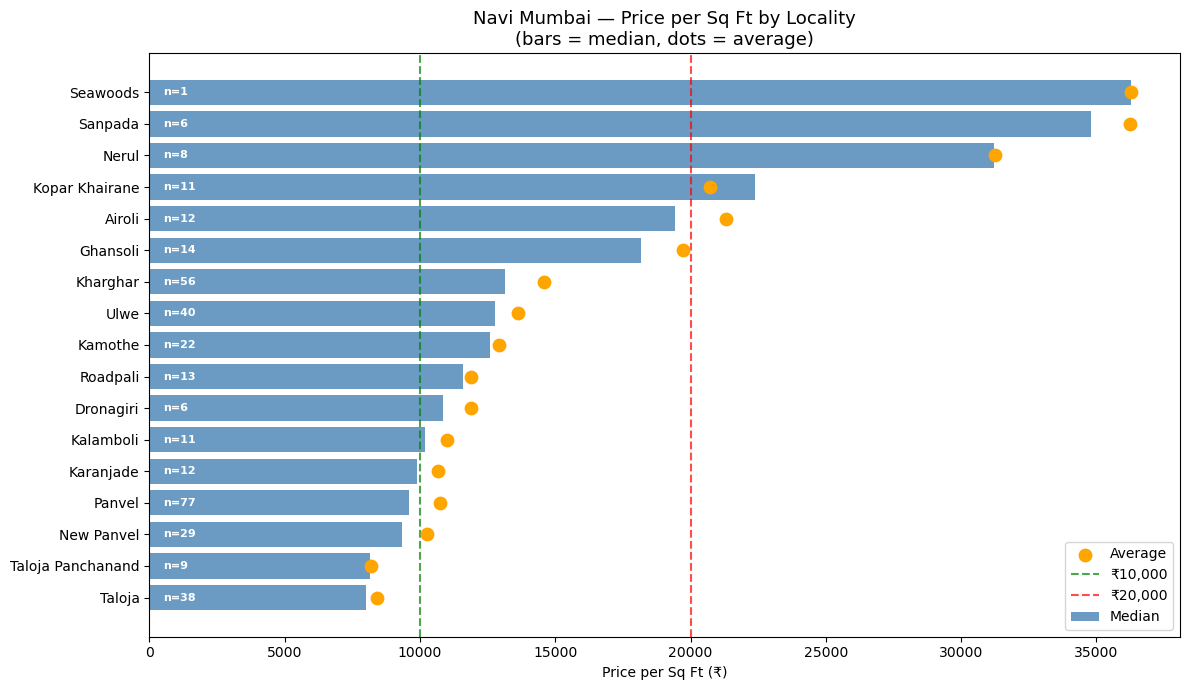

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort by median price for clean visualization
plot_data = price_analysis.reset_index().sort_values("median_price_sqft")

plt.figure(figsize=(12, 7))

# Main bars - median price
bars = plt.barh(plot_data["locality"], plot_data["median_price_sqft"], 
                color="steelblue", alpha=0.8, label="Median")

# Overlay dots - average price
plt.scatter(plot_data["avg_price_sqft"], plot_data["locality"], 
            color="orange", zorder=5, s=80, label="Average")

# Add listing count as text on each bar
for i, (_, row) in enumerate(plot_data.iterrows()):
    plt.text(500, i, f"n={row['listings']:.0f}", 
             va="center", fontsize=8, color="white", fontweight="bold")

# Reference lines
plt.axvline(x=10000, color="green", linestyle="--", alpha=0.7, label="₹10,000")
plt.axvline(x=20000, color="red", linestyle="--", alpha=0.7, label="₹20,000")

plt.xlabel("Price per Sq Ft (₹)")
plt.title("Navi Mumbai — Price per Sq Ft by Locality\n(bars = median, dots = average)", 
          fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Average price by locality AND BHK type
bhk_analysis = df_main[df_main["bhk"].isin([1, 2, 3])].groupby(
    ["locality", "bhk"]
)["price"].median().round(0) / 100000  # Convert to Lakhs

# Reshape into a table: localities as rows, BHK as columns
bhk_table = bhk_analysis.unstack("bhk")
bhk_table.columns = ["1 BHK", "2 BHK", "3 BHK"]

# Sort by 2 BHK price
bhk_table = bhk_table.sort_values("2 BHK")

print("Median Price by Locality and BHK (in Lakhs):")
print()
print(f"{'Locality':<20} {'1 BHK':>10} {'2 BHK':>10} {'3 BHK':>10}")
print("-" * 52)
for locality, row in bhk_table.iterrows():
    bhk1 = f"₹{row['1 BHK']:.0f}L" if not pd.isna(row['1 BHK']) else "N/A"
    bhk2 = f"₹{row['2 BHK']:.0f}L" if not pd.isna(row['2 BHK']) else "N/A"
    bhk3 = f"₹{row['3 BHK']:.0f}L" if not pd.isna(row['3 BHK']) else "N/A"
    print(f"{locality:<20} {bhk1:>10} {bhk2:>10} {bhk3:>10}")

Median Price by Locality and BHK (in Lakhs):

Locality                  1 BHK      2 BHK      3 BHK
----------------------------------------------------
Taloja                     ₹39L       ₹62L      ₹100L
New Panvel                 ₹43L       ₹62L      ₹115L
Taloja Panchanand          ₹37L       ₹70L        N/A
Karanjade                  ₹40L       ₹72L        N/A
Panvel                     ₹46L       ₹76L      ₹160L
Kalamboli                  ₹54L       ₹82L        N/A
Roadpali                   ₹55L       ₹87L      ₹166L
Kamothe                    ₹61L       ₹88L      ₹135L
Dronagiri                  ₹41L       ₹88L      ₹142L
Ulwe                       ₹54L       ₹95L      ₹175L
Kharghar                   ₹53L      ₹104L      ₹213L
Kopar Khairane             ₹88L      ₹125L      ₹235L
Ghansoli                   ₹74L      ₹135L      ₹273L
Airoli                     ₹82L      ₹164L      ₹208L
Sanpada                   ₹100L      ₹174L      ₹371L
Seawoods                    N/A      

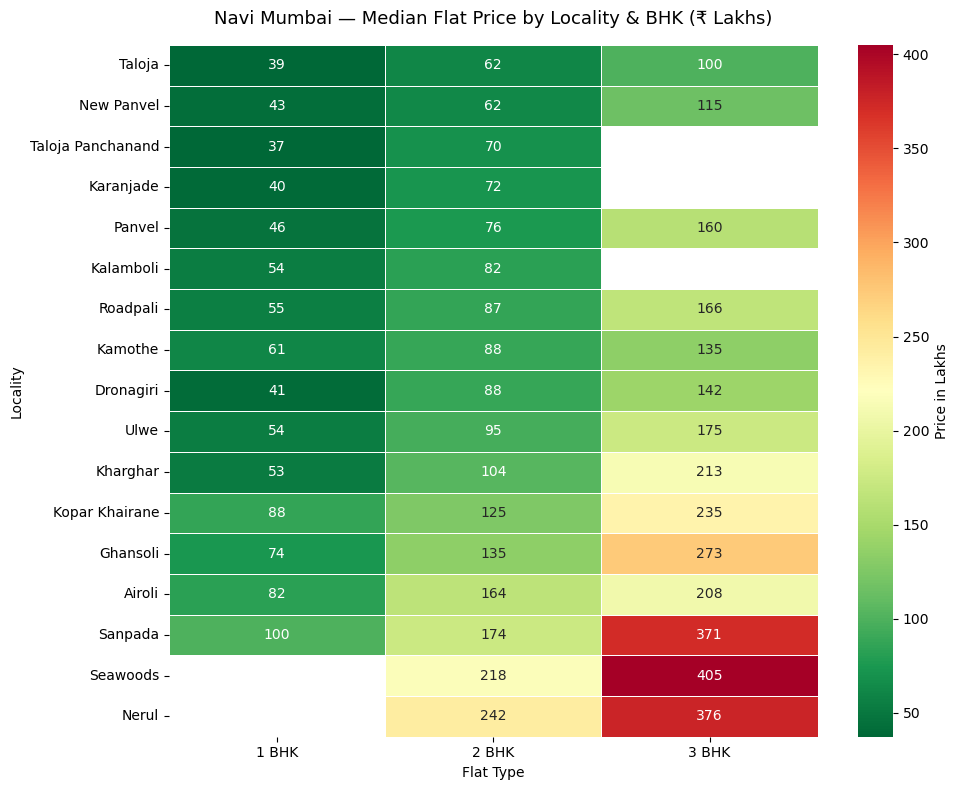

In [18]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    bhk_table,
    annot=True,           # Show numbers inside cells
    fmt=".0f",            # No decimal places
    cmap="RdYlGn_r",      # Red = expensive, Green = affordable
    linewidths=0.5,       # Grid lines between cells
    cbar_kws={"label": "Price in Lakhs"}
)

plt.title("Navi Mumbai — Median Flat Price by Locality & BHK (₹ Lakhs)", 
          fontsize=13, pad=15)
plt.xlabel("Flat Type")
plt.ylabel("Locality")
plt.tight_layout()
plt.show()

In [19]:
mumbai_url = "https://www.magicbricks.com/property-for-sale/residential-real-estate?proptype=Multistorey-Apartment,Builder-Floor-Apartment,Penthouse,Studio-Apartment&cityName=Mumbai"

response_mumbai = requests.get(mumbai_url, headers=headers)

print("Status code:", response_mumbai.status_code)
print("Response size:", len(response_mumbai.text), "characters")

# Check if same block structure exists
test_blocks = re.findall(
    r'\{[^{}]*"devName":".*?"seoDesc":".*?"\}',
    response_mumbai.text,
    re.DOTALL
)
print(f"Blocks found on page 1: {len(test_blocks)}")

Status code: 200
Response size: 1105942 characters
Blocks found on page 1: 30


In [20]:
all_blocks_combined = []

cities = {
    "Navi-Mumbai": "Navi Mumbai",
    "Mumbai": "Mumbai"
}

for city_param, city_name in cities.items():
    print(f"\nScraping {city_name}...")
    
    for page in range(1, 51):
        url = f"https://www.magicbricks.com/property-for-sale/residential-real-estate?proptype=Multistorey-Apartment,Builder-Floor-Apartment,Penthouse,Studio-Apartment&cityName={city_param}&page={page}"
        
        response = requests.get(url, headers=headers)
        
        if response.status_code == 200:
            blocks = re.findall(
                r'\{[^{}]*"devName":".*?"seoDesc":".*?"\}',
                response.text,
                re.DOTALL
            )
            
            # Tag each block with city before storing
            for block in blocks:
                all_blocks_combined.append({
                    "city" : city_name,
                    "block": block
                })
            
            print(f"  Page {page}: {len(blocks)} blocks (total: {len(all_blocks_combined)})")
        else:
            print(f"  Page {page}: Failed with status {response.status_code}")
        
        time.sleep(2)

print(f"\nDone! Total blocks: {len(all_blocks_combined)}")


Scraping Navi Mumbai...
  Page 1: 28 blocks (total: 28)
  Page 2: 29 blocks (total: 57)
  Page 3: 22 blocks (total: 79)
  Page 4: 26 blocks (total: 105)
  Page 5: 22 blocks (total: 127)
  Page 6: 18 blocks (total: 145)
  Page 7: 19 blocks (total: 164)
  Page 8: 19 blocks (total: 183)
  Page 9: 22 blocks (total: 205)
  Page 10: 25 blocks (total: 230)
  Page 11: 25 blocks (total: 255)
  Page 12: 25 blocks (total: 280)
  Page 13: 24 blocks (total: 304)
  Page 14: 25 blocks (total: 329)
  Page 15: 22 blocks (total: 351)
  Page 16: 23 blocks (total: 374)
  Page 17: 27 blocks (total: 401)
  Page 18: 24 blocks (total: 425)
  Page 19: 24 blocks (total: 449)
  Page 20: 27 blocks (total: 476)
  Page 21: 14 blocks (total: 490)
  Page 22: 0 blocks (total: 490)
  Page 23: 23 blocks (total: 513)
  Page 24: 29 blocks (total: 542)
  Page 25: 27 blocks (total: 569)
  Page 26: 28 blocks (total: 597)
  Page 27: 29 blocks (total: 626)
  Page 28: 29 blocks (total: 655)
  Page 29: 29 blocks (total: 684)
  

In [21]:
def extract_locality(desc):
    # Pattern 1: "in Ghansoli, Navi Mumbai" OR "in Bandra East, Mumbai"
    m = re.search(r'in\s+([\w\s]+),\s+(Navi Mumbai|Mumbai)', desc)
    if m:
        return m.group(1).strip()
    
    # Pattern 2: "prime location of Panvel" or "area of Mahalakshmi"
    m = re.search(r'(?:location|area) of\s+([\w\s]+?)[,\.]', desc)
    if m:
        return m.group(1).strip()
    
    # Pattern 3: "Panvel, Navi Mumbai has" OR "Borivali East, Mumbai has"
    m = re.search(r'^([\w\s]+),\s+(?:Navi Mumbai|Mumbai)\s+has', desc)
    if m:
        return m.group(1).strip()
    
    # Pattern 4: "premium Kharghar locality"
    m = re.search(r'premium\s+([\w\s]+?)\s+locality', desc)
    if m:
        return m.group(1).strip()

    # Pattern 5: "4 BHK flat in Panvel is" OR "4 BHK apartment in Kandivali West"
    m = re.search(r'\d+\s+BHK\s+\w+\s+(?:is\s+)?(?:immediately\s+)?(?:available\s+)?(?:for\s+sale\s+)?in\s+([\w\s]+?)(?:\.|,|\s+is|\s+has|\s+This)', desc)
    if m:
        return m.group(1).strip()

    # Pattern 6: "apartment in Seawoods to"
    m = re.search(r'(?:flat|apartment|residence)\s+in\s+([\w\s]+?)\s+to', desc)
    if m:
        return m.group(1).strip()

    # Pattern 7: "for sale in Kandivali West.This"
    m = re.search(r'for sale in\s+([\w\s]+?)[\.,$]', desc)
    if m:
        return m.group(1).strip()

    # Pattern 8: "Now available for sale: this 3 BHK apartment in Goregaon West, Mumbai"
    m = re.search(r'this\s+\d+\s+BHK\s+\w+\s+in\s+([\w\s]+?)(?:,|\.|$)', desc)
    if m:
        return m.group(1).strip()

    return None

print("Function updated!")

Function updated!


In [22]:
all_listings = []

for item in all_blocks_combined:
    city  = item["city"]
    block = item["block"]
    
    listing = parse_listing(block)
    listing["city"] = city
    
    all_listings.append(listing)

df_combined = pd.DataFrame(all_listings)

# Clean - drop missing critical fields
df_combined = df_combined.dropna(subset=["locality", "bhk", "price"])

# Remove duplicates
df_combined = df_combined.drop_duplicates(subset=["price", "locality", "bhk"])

# Convert bhk to int
df_combined["bhk"] = df_combined["bhk"].astype(int)

print(f"Total clean listings: {len(df_combined)}")
print(f"\nBy city:")
print(df_combined["city"].value_counts())
print(f"\nTop 10 localities overall:")
print(df_combined["locality"].value_counts().head(10))

Total clean listings: 1930

By city:
city
Mumbai         1065
Navi Mumbai     865
Name: count, dtype: int64

Top 10 localities overall:
locality
Panvel            145
Kharghar           99
Ulwe               80
Taloja             68
New Panvel         61
Andheri West       58
Goregaon West      40
Kandivali East     38
Mulund West        38
Kandivali West     35
Name: count, dtype: int64


In [23]:
# Save master dataset
df_combined.to_csv("mumbai_realestate_master.csv", index=False)

# Add price per sqft where area is available
df_with_area = df_combined.dropna(subset=["area_sqft"]).copy()
df_with_area["price_per_sqft"] = (df_with_area["price"] / df_with_area["area_sqft"]).round(0)

print(f"Master dataset saved: {len(df_combined)} listings")
print(f"Listings with area data: {len(df_with_area)}")
print(f"\nColumns in dataset:")
for col in df_combined.columns:
    non_null = df_combined[col].notna().sum()
    pct = (non_null / len(df_combined) * 100).round(1)
    print(f"  {col:<20} {non_null:>5} non-null ({pct}%)")

Master dataset saved: 1930 listings
Listings with area data: 1000

Columns in dataset:
  bhk                   1930 non-null (100.0%)
  price                 1930 non-null (100.0%)
  price_fmt             1930 non-null (100.0%)
  locality              1930 non-null (100.0%)
  developer             1930 non-null (100.0%)
  project                616 non-null (31.9%)
  area_sqft             1000 non-null (51.8%)
  possession            1838 non-null (95.2%)
  nearest_railway/metro_station  1489 non-null (77.2%)
  nearest_hospital      1535 non-null (79.5%)
  nearest_market        1315 non-null (68.1%)
  city                  1930 non-null (100.0%)


In [24]:
import pandas as pd

df = pd.read_csv(r"C:\Users\KL\Real estate\mumbai_realestate_master.csv")

# Standardize possession values
df["possession_clean"] = df["possession"].str.strip().str.lower()

def categorize_possession(val):
    if pd.isna(val):
        return "Unknown"
    val = str(val).strip().lower()
    if val == "ready to move":
        return "Ready to Move"
    else:
        return "Under Construction"

df["possession_status"] = df["possession_clean"].apply(categorize_possession)

print("Possession status distribution:")
print(df["possession_status"].value_counts())

Possession status distribution:
possession_status
Ready to Move         1408
Under Construction     430
Unknown                 92
Name: count, dtype: int64


In [25]:
df.to_csv(r"C:\Users\KL\Real estate\mumbai_realestate_master.csv", index=False)
print(f"Saved! Columns: {df.columns.tolist()}")

Saved! Columns: ['bhk', 'price', 'price_fmt', 'locality', 'developer', 'project', 'area_sqft', 'possession', 'nearest_railway/metro_station', 'nearest_hospital', 'nearest_market', 'city', 'possession_clean', 'possession_status']


In [26]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Use only rows with all required features
model_data = df.dropna(subset=["bhk", "area_sqft", "locality", "city", "price"]).copy()

# Remove extreme outliers above 99th percentile
p99 = model_data["price"].quantile(0.99)
model_data = model_data[model_data["price"] <= p99]

print(f"Training rows after outlier removal: {len(model_data)}")

# Encode locality and city as numbers — Random Forest needs numbers not text
le_locality = LabelEncoder()
le_city = LabelEncoder()

model_data["locality_encoded"] = le_locality.fit_transform(model_data["locality"])
model_data["city_encoded"]     = le_city.fit_transform(model_data["city"])

# Features and target
X = model_data[["bhk", "area_sqft", "locality_encoded", "city_encoded"]]
y = model_data["price"]

print(f"Features: {X.columns.tolist()}")

Training rows after outlier removal: 990
Features: ['bhk', 'area_sqft', 'locality_encoded', 'city_encoded']


In [27]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"R2 Score: {r2:.3f}  (1.0 = perfect)")
print(f"Mean Absolute Error: Rs {mae/100000:.1f} Lakhs")

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importance:")
for feat, imp in importances.items():
    print(f"  {feat}: {imp:.3f}")

R2 Score: 0.806  (1.0 = perfect)
Mean Absolute Error: Rs 81.2 Lakhs
Feature Importance:
  area_sqft: 0.810
  locality_encoded: 0.101
  city_encoded: 0.071
  bhk: 0.018


In [28]:
import pickle

with open(r"C:\Users\KL\Real estate\price_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open(r"C:\Users\KL\Real estate\le_locality.pkl", "wb") as f:
    pickle.dump(le_locality, f)

with open(r"C:\Users\KL\Real estate\le_city.pkl", "wb") as f:
    pickle.dump(le_city, f)

print("Model and encoders saved!")

# Test prediction
test_input = pd.DataFrame(
    [[2, 900, le_locality.transform(["Kharghar"])[0], le_city.transform(["Navi Mumbai"])[0]]],
    columns=["bhk", "area_sqft", "locality_encoded", "city_encoded"]
)
predicted = model.predict(test_input)[0]
print(f"Test: 2 BHK 900 sqft Kharghar -> Rs {predicted/100000:.1f}L")

Model and encoders saved!
Test: 2 BHK 900 sqft Kharghar -> Rs 95.6L
